# Ni-WC SEM Microstructure Segmentation

This notebook is the reproducible research workflow for the manuscript experiments. It implements the fixed cross-magnification benchmark, trains only the paper-reported models, saves all numeric artifacts as CSV files, and exports manuscript-style figures in PNG, TIFF, and SVG formats.

**Experimental design.** Training and validation use `sem1000`, `sem800`, and `sem700`; `sem600` is held out as the independent test magnification. All deep models are trained for five seeds with the same preprocessing, augmentation, optimizer, scheduler, and weighted focal-Dice objective. The final selected inference recipe is U-Net++ with a ResNet34 ImageNet-pretrained encoder, EMA checkpointing, and geometric test-time augmentation.

## Notebook Map

1. Environment and global configuration
2. Dataset manifest, label mapping, and fixed split
3. Dataset diagnostics and visual checks
4. Model registry and transfer-learning settings
5. Dataset objects, augmentation, and loaders
6. Loss, metrics, and model builders
7. EMA, TTA, training loop, and artifact writers
8. Model training
9. Result aggregation and manuscript figures
10. Final-model material characterization

## 1. Environment

In [2]:
from __future__ import annotations

import copy
import json
import math
import os
import random
import re
import shutil
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from PIL import Image
from scipy import ndimage as ndi
from skimage import measure
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.encoders import encoders as SMP_ENCODERS
from segmentation_models_pytorch.encoders import pretrained_settings as SMP_PRETRAINED_SETTINGS
from transformers import AutoModelForSemanticSegmentation

PROJECT_ROOT = Path.cwd()

## 2. Experiment Configuration

All experiment constants are defined in one place. The notebook assumes a CUDA runtime and keeps image/mask tensors on GPU memory for the training run.

In [3]:
@dataclass(frozen=True)
class Config:
    image_dir: Path = PROJECT_ROOT / "data" / "AugmentedImages"
    mask_dir: Path = PROJECT_ROOT / "data" / "AugmentedMasks"
    output_dir: Path = PROJECT_ROOT / "paper_outputs"

    raw_to_train_label: dict[int, int] = None
    ignore_index: int = 255
    class_names: tuple[str, ...] = ("matrix", "carbide_particles", "dilution_band", "reprecipitated_carbides")
    palette: tuple[tuple[int, int, int], ...] = (
        (47, 79, 79),
        (219, 95, 52),
        (57, 106, 177),
        (132, 186, 91),
    )

    image_size: int = 512
    train_sources: tuple[str, ...] = ("sem1000", "sem800", "sem700")
    holdout_source: str = "sem600"
    validation_patch_stride: int = 6
    validation_patch_offset: int = 0

    seed_values: tuple[int, ...] = (1, 2, 3, 4, 5)
    batch_size: int = 8
    eval_batch_size: int = 64
    num_workers: int = os.cpu_count() or 8
    cache_tensors_on_gpu: bool = True
    epochs: int = 200
    patience: int = 15
    learning_rate: float = 2e-4
    eta_min: float = 1e-6
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    fused_adamw: bool = True
    amp_dtype: torch.dtype = torch.bfloat16
    channels_last: bool = True
    ema_decay: float = 0.995

    focal_gamma: float = 2.0
    focal_weight: float = 0.5
    dice_weight: float = 0.5
    minority_sampler_strength: float = 2.0
    surface_tolerance_px: float = 2.0

    brightness_jitter: float = 0.08
    contrast_jitter: float = 0.12
    gamma_jitter: float = 0.10
    gaussian_noise_std: float = 3.0

    tta_transforms: tuple[str, ...] = ("identity", "hflip", "vflip", "rot90", "rot180", "rot270", "transpose", "anti_transpose")


CFG = Config(raw_to_train_label={1: 0, 3: 1, 4: 2, 5: 3})

TABLE_DIR = CFG.output_dir / "tables"
FIGURE_DIR = CFG.output_dir / "figures"
CHECKPOINT_DIR = CFG.output_dir / "checkpoints"
PREDICTION_DIR = CFG.output_dir / "predictions"
for path in (TABLE_DIR, FIGURE_DIR, CHECKPOINT_DIR, PREDICTION_DIR):
    path.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

TRAIN_TO_RAW_LABEL = {train_id: raw_id for raw_id, train_id in CFG.raw_to_train_label.items()}
ID2LABEL = dict(enumerate(CFG.class_names))
LABEL2ID = {name: idx for idx, name in ID2LABEL.items()}

DEVICE

device(type='cuda')

## 3. Manuscript Figure Style

The plotting style matches `ni_wc_trans_sam_benchmark.py`: small manuscript-scale fonts, black axes, major/minor grids, and the purple-gray-teal palette used in the existing results.

In [4]:
THEME = {
    "purple": "#9671bd",
    "purple_edge": "#6a408d",
    "gray": "#7e7e7e",
    "gray_edge": "#4e4e4e",
    "teal": "#77b5b6",
    "teal_edge": "#378d94",
    "neutral": "#8a8a8a",
    "warm": "#d98c5f",
    "warm_edge": "#9c5c37",
}

def set_paper_style() -> None:
    mpl.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans"],
        "font.size": 7.5,
        "axes.titlesize": 8.0,
        "axes.labelsize": 7.5,
        "xtick.labelsize": 6.8,
        "ytick.labelsize": 6.8,
        "legend.fontsize": 6.8,
        "figure.titlesize": 8.0,
        "figure.dpi": 120,
        "savefig.dpi": 600,
        "axes.linewidth": 0.75,
        "axes.spines.top": True,
        "axes.spines.right": True,
        "xtick.major.width": 0.75,
        "ytick.major.width": 0.75,
        "xtick.major.size": 3.5,
        "ytick.major.size": 3.5,
        "xtick.minor.size": 2.0,
        "ytick.minor.size": 2.0,
        "legend.frameon": False,
        "figure.constrained_layout.use": False,
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "lines.linewidth": 1.7,
        "patch.linewidth": 1.2,
    })


def apply_axis_style(ax: mpl.axes.Axes, grid: bool = True) -> None:
    if grid:
        ax.grid(True, which="major", linestyle="-", linewidth=0.55, alpha=0.25)
        ax.minorticks_on()
        ax.grid(True, which="minor", linestyle="-", linewidth=0.25, alpha=0.15)
    ax.set_axisbelow(True)


def save_figure(fig: mpl.figure.Figure, stem: Path) -> None:
    stem.parent.mkdir(parents=True, exist_ok=True)
    for ext in ("png", "tiff", "svg"):
        fig.savefig(stem.with_suffix(f".{ext}"), bbox_inches="tight", dpi=600, facecolor="white")
    plt.close(fig)


def show_and_save(fig: mpl.figure.Figure, stem: Path) -> None:
    display(fig)
    save_figure(fig, stem)


def class_label(name: str) -> str:
    return name.replace("_", " ").title()


set_paper_style()

## 4. Reproducibility Utilities

In [5]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def autocast_context(enabled: bool = True):
    return torch.autocast(device_type="cuda", dtype=CFG.amp_dtype, enabled=enabled)


def clean_state_dict(model: nn.Module) -> dict[str, torch.Tensor]:
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def load_state_dict(model: nn.Module, state: dict[str, torch.Tensor]) -> None:
    model.load_state_dict({k: v.to(DEVICE) for k, v in state.items()}, strict=True)

## 5. Dataset I/O and Label Mapping

Masks are remapped from raw label IDs to contiguous training IDs. Raw label `2` is ignored during optimization and metric computation.

In [6]:
FILENAME_RE = re.compile(r"^(sem\d+)_x(\d+)_y(\d+)(?:_(.+))?$")


def load_rgb(path: Path) -> np.ndarray:
    return np.array(Image.open(path).convert("RGB"), dtype=np.uint8)


def load_mask(path: Path) -> np.ndarray:
    return np.array(Image.open(path), dtype=np.uint8)


def remap_mask(mask: np.ndarray) -> np.ndarray:
    out = np.full(mask.shape, CFG.ignore_index, dtype=np.uint8)
    for raw_id, train_id in CFG.raw_to_train_label.items():
        out[mask == raw_id] = train_id
    return out


def parse_filename(path: Path) -> dict[str, Any]:
    match = FILENAME_RE.match(path.stem)
    if match is None:
        raise ValueError(f"Unexpected tile filename: {path.name}")
    source_id, x, y, augmentation = match.groups()
    return {
        "filename": path.name,
        "source_id": source_id,
        "x_coord": int(x),
        "y_coord": int(y),
        "patch_key": f"{source_id}_x{x}_y{y}",
        "augmentation": augmentation or "canonical",
        "is_augmented": augmentation is not None,
    }

## 6. Fixed Split Construction

The split is source-aware: `sem600` is held out for testing, while validation is selected by independent patch identity from the remaining magnification sources.

In [7]:
def collect_manifest() -> tuple[pd.DataFrame, pd.DataFrame]:
    rows, raw_counts = [], {}
    mask_by_name = {p.name: p for p in CFG.mask_dir.glob("*.bmp")}
    for image_path in sorted(CFG.image_dir.glob("*.bmp")):
        mask_path = mask_by_name.get(image_path.name)
        if mask_path is None:
            continue
        raw_mask = load_mask(mask_path)
        mapped_mask = remap_mask(raw_mask)
        for raw_id, count in zip(*np.unique(raw_mask, return_counts=True)):
            raw_counts[int(raw_id)] = raw_counts.get(int(raw_id), 0) + int(count)
        row = {
            **parse_filename(image_path),
            "image_path": str(image_path),
            "mask_path": str(mask_path),
            "height": mapped_mask.shape[0],
            "width": mapped_mask.shape[1],
            "ignored_pixels": int((mapped_mask == CFG.ignore_index).sum()),
        }
        for class_id in range(len(CFG.class_names)):
            row[f"class_{class_id}_pixels"] = int((mapped_mask == class_id).sum())
        rows.append(row)

    manifest = pd.DataFrame(rows).sort_values(["source_id", "patch_key", "augmentation", "filename"]).reset_index(drop=True)
    raw_label_df = pd.DataFrame([{"raw_label_id": k, "pixels": v} for k, v in sorted(raw_counts.items())])
    raw_label_df["percent"] = 100 * raw_label_df["pixels"] / raw_label_df["pixels"].sum()
    raw_label_df["status"] = raw_label_df["raw_label_id"].map(lambda x: "retained" if x in CFG.raw_to_train_label else "ignored")
    raw_label_df["train_class_id"] = raw_label_df["raw_label_id"].map(CFG.raw_to_train_label)
    raw_label_df["class_name"] = raw_label_df["train_class_id"].map(ID2LABEL)
    return manifest, raw_label_df


def fixed_split(manifest: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_pool = manifest[manifest["source_id"].isin(CFG.train_sources)].copy()
    test_df = manifest[manifest["source_id"] == CFG.holdout_source].copy()
    patches = sorted(train_pool["patch_key"].unique())
    val_patches = {p for i, p in enumerate(patches) if i % CFG.validation_patch_stride == CFG.validation_patch_offset}
    train_df = train_pool[~train_pool["patch_key"].isin(val_patches)].copy()
    val_df = train_pool[train_pool["patch_key"].isin(val_patches)].copy()
    split_df = pd.concat([
        train_df.assign(split="train"),
        val_df.assign(split="val"),
        test_df.assign(split="test"),
    ], ignore_index=True)
    sort_cols = ["source_id", "patch_key", "augmentation", "filename"]
    return (
        train_df.sort_values(sort_cols).reset_index(drop=True),
        val_df.sort_values(sort_cols).reset_index(drop=True),
        test_df.sort_values(sort_cols).reset_index(drop=True),
        split_df.sort_values(["split", *sort_cols]).reset_index(drop=True),
    )


def audit_split(manifest: pd.DataFrame, train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame) -> pd.DataFrame:
    row = {
        "total_tiles": len(manifest),
        "unique_patches": manifest["patch_key"].nunique(),
        "train_tiles": len(train_df),
        "val_tiles": len(val_df),
        "test_tiles": len(test_df),
        "train_patches": train_df["patch_key"].nunique(),
        "val_patches": val_df["patch_key"].nunique(),
        "test_patches": test_df["patch_key"].nunique(),
        "train_val_patch_overlap": len(set(train_df.patch_key) & set(val_df.patch_key)),
        "train_test_patch_overlap": len(set(train_df.patch_key) & set(test_df.patch_key)),
        "val_test_patch_overlap": len(set(val_df.patch_key) & set(test_df.patch_key)),
        "train_test_source_overlap": len(set(train_df.source_id) & set(test_df.source_id)),
        "val_test_source_overlap": len(set(val_df.source_id) & set(test_df.source_id)),
    }
    audit = pd.DataFrame([row])
    leakage = [c for c in audit.columns if c.endswith("_overlap")]
    if int(audit.loc[0, leakage].sum()) != 0:
        raise RuntimeError("Patch/source leakage detected in the fixed split.")
    return audit


def class_distribution(df: pd.DataFrame, split: str) -> pd.DataFrame:
    pixels = np.array([df[f"class_{i}_pixels"].sum() for i in range(len(CFG.class_names))], dtype=np.float64)
    return pd.DataFrame({
        "split": split,
        "class_id": np.arange(len(CFG.class_names)),
        "raw_label_id": [TRAIN_TO_RAW_LABEL[i] for i in range(len(CFG.class_names))],
        "class_name": CFG.class_names,
        "pixels": pixels.astype(np.int64),
        "percent_retained": 100 * pixels / pixels.sum(),
    })


MANIFEST_DF, RAW_LABEL_DF = collect_manifest()
TRAIN_DF, VAL_DF, TEST_DF, SPLIT_DF = fixed_split(MANIFEST_DF)
SPLIT_AUDIT_DF = audit_split(MANIFEST_DF, TRAIN_DF, VAL_DF, TEST_DF)
CLASS_DISTRIBUTION_DF = pd.concat([
    class_distribution(TRAIN_DF, "train"),
    class_distribution(VAL_DF, "val"),
    class_distribution(TEST_DF, "test"),
], ignore_index=True)

MANIFEST_DF.to_csv(TABLE_DIR / "manifest.csv", index=False)
SPLIT_DF.to_csv(TABLE_DIR / "split_manifest.csv", index=False)
RAW_LABEL_DF.to_csv(TABLE_DIR / "raw_label_audit.csv", index=False)
SPLIT_AUDIT_DF.to_csv(TABLE_DIR / "split_audit.csv", index=False)
CLASS_DISTRIBUTION_DF.to_csv(TABLE_DIR / "class_distribution_by_split.csv", index=False)

SPLIT_AUDIT_DF

,total_tiles,unique_patches,train_tiles,val_tiles,test_tiles,train_patches,val_patches,test_patches,train_val_patch_overlap,train_test_patch_overlap,val_test_patch_overlap,train_test_source_overlap,val_test_source_overlap
0,405,45,243,54,108,27,6,12,0,0,0,0,0


## 7. Dataset Diagnostics

These cells save and display the split/class-distribution figures used to document the dataset.

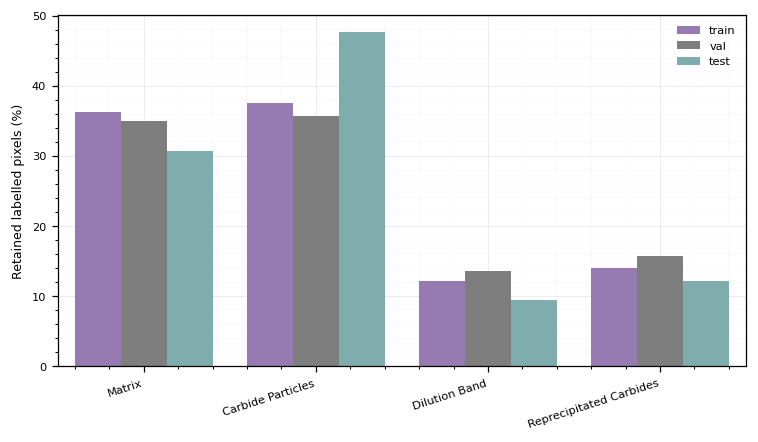

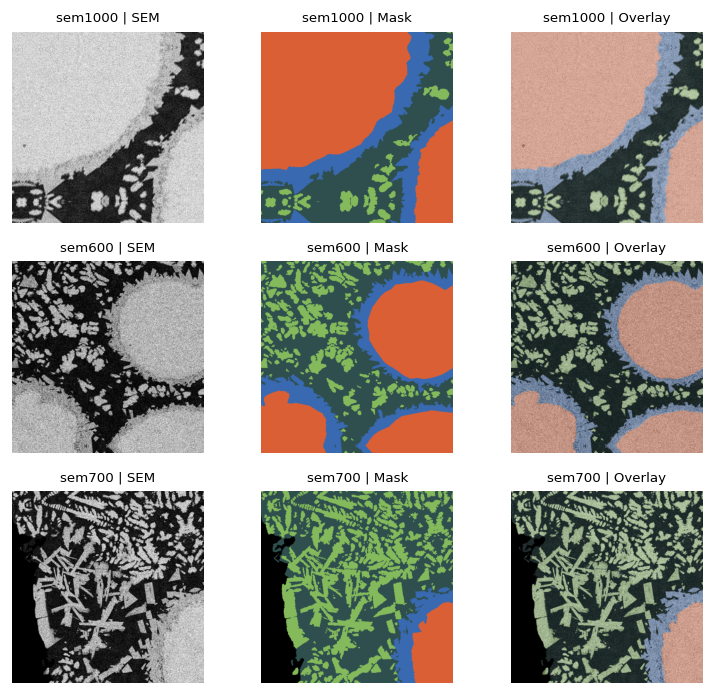

In [8]:
def plot_class_distribution() -> mpl.figure.Figure:
    fig, ax = plt.subplots(figsize=(7.4, 3.8))
    table = CLASS_DISTRIBUTION_DF.copy()
    sns.barplot(
        data=table,
        x="class_name",
        y="percent_retained",
        hue="split",
        hue_order=["train", "val", "test"],
        palette=[THEME["purple"], THEME["gray"], THEME["teal"]],
        ax=ax,
    )
    ax.set_xlabel("")
    ax.set_ylabel("Retained labelled pixels (%)")
    labels = [class_label(t.get_text()) for t in ax.get_xticklabels()]
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(labels, rotation=18, ha="right")
    ax.legend(title="")
    apply_axis_style(ax)
    return fig


def plot_dataset_examples(n: int = 3) -> mpl.figure.Figure:
    examples = MANIFEST_DF[MANIFEST_DF["augmentation"] == "canonical"].groupby("source_id", sort=True).head(1).head(n)
    if examples.empty:
        examples = MANIFEST_DF.groupby("source_id", sort=True).head(1).head(n)
    if examples.empty:
        fig, ax = plt.subplots(figsize=(5.2, 2.0))
        ax.text(0.5, 0.5, "No paired image-mask examples found", ha="center", va="center")
        ax.axis("off")
        return fig

    fig, axes = plt.subplots(len(examples), 3, figsize=(7.6, 2.35 * len(examples)), squeeze=False)
    colors = np.array(CFG.palette, dtype=np.uint8)
    for row_idx, row in enumerate(examples.itertuples()):
        image = load_rgb(Path(row.image_path))
        mask = remap_mask(load_mask(Path(row.mask_path)))
        mask_rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
        valid = mask != CFG.ignore_index
        mask_rgb[valid] = colors[mask[valid]]
        if mask_rgb.shape[:2] != image.shape[:2]:
            mask_rgb = np.array(Image.fromarray(mask_rgb).resize((image.shape[1], image.shape[0]), resample=Image.Resampling.NEAREST))
        overlay = (0.62 * image + 0.38 * mask_rgb).astype(np.uint8)
        for ax, arr, title in zip(axes[row_idx], [image, mask_rgb, overlay], ["SEM", "Mask", "Overlay"]):
            ax.imshow(arr)
            ax.set_title(f"{row.source_id} | {title}")
            ax.axis("off")
    return fig


show_and_save(plot_class_distribution(), FIGURE_DIR / "dataset_class_distribution_by_split")
show_and_save(plot_dataset_examples(), FIGURE_DIR / "dataset_image_mask_examples")

## 8. Model Registry

Only the models reported in the manuscript are included. MicroNet weights are registered as an SMP encoder-pretraining option so ImageNet and MicroNet variants differ only by encoder initialization.

In [9]:
MICRONET_URLS = {
    "resnet34": "https://huggingface.co/jstuckner/microscopy-resnet34-imagenet-micronet/resolve/main/resnet34_imagenet-micronet_weights.pth",
    "efficientnet-b3": "https://huggingface.co/jstuckner/microscopy-efficientnet-b3-imagenet-micronet/resolve/main/efficientnet-b3_imagenet-micronet_weights.pth",
}

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


def register_micronet_weights() -> None:
    for encoder_name, url in MICRONET_URLS.items():
        base = dict(SMP_ENCODERS[encoder_name]["pretrained_settings"]["imagenet"])
        base.update({
            "url": url,
            "repo_id": f"jstuckner/microscopy-{encoder_name}-imagenet-micronet",
            "revision": "main",
            "input_space": "RGB",
            "input_range": [0, 1],
            "mean": IMAGENET_MEAN,
            "std": IMAGENET_STD,
        })
        SMP_ENCODERS[encoder_name]["pretrained_settings"]["micronet"] = base
        SMP_PRETRAINED_SETTINGS.setdefault(encoder_name, {})["micronet"] = base


register_micronet_weights()


@dataclass(frozen=True)
class ModelSpec:
    name: str
    family: str
    implementation: str
    architecture: str
    encoder_name: str
    encoder_weights: str
    mean: tuple[float, float, float]
    std: tuple[float, float, float]
    ema: bool = False
    tta: bool = False


def preprocessing_params(encoder_name: str, weights: str) -> tuple[tuple[float, ...], tuple[float, ...]]:
    if weights == "micronet":
        return IMAGENET_MEAN, IMAGENET_STD
    params = smp.encoders.get_preprocessing_params(encoder_name, pretrained=weights)
    return tuple(params["mean"]), tuple(params["std"])


def make_spec(name: str, family: str, architecture: str, encoder_name: str, encoder_weights: str, ema: bool = False, tta: bool = False) -> ModelSpec:
    mean, std = preprocessing_params(encoder_name, encoder_weights)
    return ModelSpec(name, family, "smp", architecture, encoder_name, encoder_weights, mean, std, ema, tta)


MODEL_SPECS = {
    "unet_resnet34_imagenet": make_spec("unet_resnet34_imagenet", "U-Net", "unet", "resnet34", "imagenet"),
    "unet_resnet34_micronet": make_spec("unet_resnet34_micronet", "U-Net", "unet", "resnet34", "micronet"),
    "unet_effb3_imagenet": make_spec("unet_effb3_imagenet", "U-Net", "unet", "efficientnet-b3", "imagenet"),
    "unet_effb3_micronet": make_spec("unet_effb3_micronet", "U-Net", "unet", "efficientnet-b3", "micronet"),
    "unetpp_resnet34": make_spec("unetpp_resnet34", "U-Net++", "unetpp", "resnet34", "imagenet"),
    "unetpp_resnet34_micronet": make_spec("unetpp_resnet34_micronet", "U-Net++", "unetpp", "resnet34", "micronet"),
    "unetpp_effb3_imagenet": make_spec("unetpp_effb3_imagenet", "U-Net++", "unetpp", "efficientnet-b3", "imagenet"),
    "unetpp_effb3_micronet": make_spec("unetpp_effb3_micronet", "U-Net++", "unetpp", "efficientnet-b3", "micronet"),
    "deeplabv3plus_resnet34_imagenet": make_spec("deeplabv3plus_resnet34_imagenet", "DeepLabV3+", "deeplabv3plus", "resnet34", "imagenet"),
    "deeplabv3plus_resnet34_micronet": make_spec("deeplabv3plus_resnet34_micronet", "DeepLabV3+", "deeplabv3plus", "resnet34", "micronet"),
    "deeplabv3plus_effb3_imagenet": make_spec("deeplabv3plus_effb3_imagenet", "DeepLabV3+", "deeplabv3plus", "efficientnet-b3", "imagenet"),
    "deeplabv3plus_effb3_micronet": make_spec("deeplabv3plus_effb3_micronet", "DeepLabV3+", "deeplabv3plus", "efficientnet-b3", "micronet"),
    "segformer_mit_b0": ModelSpec("segformer_mit_b0", "SegFormer", "transformers", "segformer", "nvidia/mit-b0", "imagenet-1k", IMAGENET_MEAN, IMAGENET_STD),
    "unetpp_resnet34_final": make_spec("unetpp_resnet34_final", "U-Net++", "unetpp", "resnet34", "imagenet", ema=True, tta=True),
}

PAPER_MODEL_NAMES = tuple(MODEL_SPECS)
pd.DataFrame([asdict(spec) for spec in MODEL_SPECS.values()]).to_csv(TABLE_DIR / "model_registry.csv", index=False)
pd.DataFrame([asdict(spec) for spec in MODEL_SPECS.values()])

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

,name,family,implementation,architecture,encoder_name,encoder_weights,mean,std,ema,tta
0,unet_resnet34_imagenet,U-Net,smp,unet,resnet34,imagenet,"(0.485, 0.456, 0.406)","(0.229, 0.224, 0.225)",False,False
1,unet_resnet34_micronet,U-Net,smp,unet,resnet34,micronet,"(0.485, 0.456, 0.406)","(0.229, 0.224, 0.225)",False,False
2,unet_effb3_imagenet,U-Net,smp,unet,efficientnet-b3,imagenet,"(0.485, 0.456, 0.406)","(0.229, 0.224, 0.225)",False,False
3,unet_effb3_micronet,U-Net,smp,unet,efficientnet-b3,micronet,"(0.485, 0.456, 0.406)","(0.229, 0.224, 0.225)",False,False
4,unetpp_resnet34,U-Net++,smp,unetpp,resnet34,imagenet,"(0.485, 0.456, 0.406)","(0.229, 0.224, 0.225)",False,False
5,unetpp_resnet34_micronet,U-Net++,smp,unetpp,resnet34,micronet,"(0.485, 0.456, 0.406)","(0.229, 0.224, 0.225)",False,False
6,unetpp_effb3_imagenet,U-Net++,smp,unetpp,efficientnet-b3,imagenet,"(0.485, 0.456, 0.406)","(0.229, 0.224, 0.225)",False,False
7,unetpp_effb3_micronet,U-Net++,smp,unetpp,efficientnet-b3,micronet,"(0.485, 0.456, 0.406)","(0.229, 0.224, 0.225)",False,False
8,deeplabv3plus_resnet34_imagenet,DeepLabV3+,smp,deeplabv3plus,resnet34,imagenet,"(0.485, 0.456, 0.406)","(0.229, 0.224, 0.225)",False,False
9,deeplabv3plus_resnet34_micronet,DeepLabV3+,smp,deeplabv3plus,resnet34,micronet,"(0.485, 0.456, 0.406)","(0.229, 0.224, 0.225)",False,False


## 9. Dataset Objects and Augmentation

Training uses SEM-preserving geometric augmentation and intensity perturbations. Train, validation, and test tensors are cached once and then reused across all model/seed runs.

In [10]:
def intensity_augment(image: torch.Tensor) -> torch.Tensor:
    image = image.float()
    image = image + (torch.rand((), device=image.device) * 2 - 1) * CFG.brightness_jitter * 255
    mean = image.mean(dim=(1, 2), keepdim=True)
    contrast = 1 + (torch.rand((), device=image.device) * 2 - 1) * CFG.contrast_jitter
    image = (image - mean) * contrast + mean
    gamma = 1 + (torch.rand((), device=image.device) * 2 - 1) * CFG.gamma_jitter
    image = 255 * torch.clamp(image / 255, 0, 1).pow(gamma)
    image = image + torch.randn_like(image) * CFG.gaussian_noise_std
    return torch.clamp(image, 0, 255).to(torch.uint8)


class NiWCDataset(Dataset):
    def __init__(self, df: pd.DataFrame, training: bool):
        self.df = df.reset_index(drop=True)
        self.training = training
        self.cache = [self._load(i) for i in range(len(self.df))]
        if CFG.cache_tensors_on_gpu:
            self.cache = [{**item, "image": item["image"].to(DEVICE), "mask": item["mask"].to(DEVICE)} for item in self.cache]

    def _load(self, idx: int) -> dict[str, Any]:
        row = self.df.iloc[idx]
        image = torch.from_numpy(load_rgb(Path(row.image_path))).permute(2, 0, 1).contiguous()
        mask = torch.from_numpy(remap_mask(load_mask(Path(row.mask_path)))).long()
        return {
            "image": image,
            "mask": mask,
            "filename": row.filename,
            "source_id": row.source_id,
            "patch_key": row.patch_key,
            "image_path": row.image_path,
            "mask_path": row.mask_path,
        }

    def __len__(self) -> int:
        return len(self.cache)

    def __getitem__(self, idx: int) -> dict[str, Any]:
        item = self.cache[idx].copy()
        image, mask = item["image"], item["mask"]
        if self.training:
            if torch.rand((), device=image.device) < 0.5:
                image, mask = torch.flip(image, [-1]), torch.flip(mask, [-1])
            if torch.rand((), device=image.device) < 0.5:
                image, mask = torch.flip(image, [-2]), torch.flip(mask, [-2])
            k = int(torch.randint(0, 4, (), device=image.device).item())
            if k:
                image, mask = torch.rot90(image, k, [-2, -1]), torch.rot90(mask, k, [-2, -1])
            image = intensity_augment(image)
        item["image"], item["mask"] = image, mask
        return item


def collate_batch(batch: list[dict[str, Any]], mean: tuple[float, ...], std: tuple[float, ...]) -> dict[str, Any]:
    images = torch.stack([x["image"] for x in batch]).float().div_(255.0)
    mean_t = torch.tensor(mean, dtype=images.dtype, device=images.device)[None, :, None, None]
    std_t = torch.tensor(std, dtype=images.dtype, device=images.device)[None, :, None, None]
    return {
        "pixel_values": (images - mean_t) / std_t,
        "labels": torch.stack([x["mask"] for x in batch]),
        "raw_images": [x["image"] for x in batch],
        "filenames": [x["filename"] for x in batch],
        "source_ids": [x["source_id"] for x in batch],
        "patch_keys": [x["patch_key"] for x in batch],
        "image_paths": [x["image_path"] for x in batch],
        "mask_paths": [x["mask_path"] for x in batch],
    }

## 10. Class Weights, Sampler, and Loaders

Class imbalance is handled with class-weighted focal loss and minority-aware weighted sampling of training tiles.

In [11]:
def class_weights(df: pd.DataFrame) -> tuple[torch.Tensor, pd.DataFrame]:
    pixels = np.array([df[f"class_{i}_pixels"].sum() for i in range(len(CFG.class_names))], dtype=np.float64)
    freq = pixels / pixels.sum()
    weights = 1 / np.sqrt(np.maximum(freq, 1e-12))
    weights = np.clip(weights / weights.mean(), 0.5, 3.0)
    table = pd.DataFrame({"class_name": CFG.class_names, "pixels": pixels.astype(np.int64), "frequency": freq, "class_weight": weights})
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE), table


def sample_weights(df: pd.DataFrame) -> pd.DataFrame:
    retained = sum(df[f"class_{i}_pixels"].to_numpy(float) for i in range(len(CFG.class_names)))
    minority = df["class_2_pixels"].to_numpy(float) + df["class_3_pixels"].to_numpy(float)
    minority_fraction = minority / np.maximum(retained, 1)
    weights = 1 + CFG.minority_sampler_strength * (minority_fraction / max(minority_fraction.mean(), 1e-8) - 1)
    weights = np.clip(weights, 0.25, 4.0)
    return df[["filename", "source_id", "patch_key"]].assign(minority_fraction=minority_fraction, sample_weight=weights / weights.mean())


CLASS_WEIGHTS, CLASS_WEIGHT_DF = class_weights(TRAIN_DF)
SAMPLE_WEIGHT_DF = sample_weights(TRAIN_DF)
CLASS_WEIGHT_DF.to_csv(TABLE_DIR / "class_weights.csv", index=False)
SAMPLE_WEIGHT_DF.to_csv(TABLE_DIR / "training_sample_weights.csv", index=False)

TRAIN_DATASET = NiWCDataset(TRAIN_DF, training=True)
VAL_DATASET = NiWCDataset(VAL_DF, training=False)
TEST_DATASET = NiWCDataset(TEST_DF, training=False)


def build_loaders(spec: ModelSpec, seed: int) -> tuple[DataLoader, DataLoader, DataLoader]:
    generator = torch.Generator().manual_seed(seed)
    sampler_generator = torch.Generator().manual_seed(seed + 10_000)
    sampler = WeightedRandomSampler(
        torch.tensor(SAMPLE_WEIGHT_DF["sample_weight"].to_numpy(copy=True), dtype=torch.double),
        len(TRAIN_DATASET),
        replacement=True,
        generator=sampler_generator,
    )
    gpu_cached = CFG.cache_tensors_on_gpu
    worker_count = 0 if gpu_cached else CFG.num_workers
    loader_args = {
        "num_workers": worker_count,
        "pin_memory": not gpu_cached,
        "persistent_workers": worker_count > 0,
        "worker_init_fn": seed_worker if worker_count > 0 else None,
        "generator": generator,
    }
    if worker_count > 0:
        loader_args["prefetch_factor"] = 4
    collate = lambda batch: collate_batch(batch, spec.mean, spec.std)
    return (
        DataLoader(TRAIN_DATASET, batch_size=CFG.batch_size, sampler=sampler, collate_fn=collate, **loader_args),
        DataLoader(VAL_DATASET, batch_size=CFG.eval_batch_size, shuffle=False, collate_fn=collate, **loader_args),
        DataLoader(TEST_DATASET, batch_size=CFG.eval_batch_size, shuffle=False, collate_fn=collate, **loader_args),
    )


CLASS_WEIGHT_DF

,class_name,pixels,frequency,class_weight
0,matrix,22945881,0.362678,0.752191
1,carbide_particles,23760693,0.375557,0.739181
2,dilution_band,7716367,0.121963,1.297102
3,reprecipitated_carbides,8844947,0.139802,1.211526


## 11. Objective Function

The optimization target is a weighted focal loss combined with soft Dice loss.

In [12]:
class WeightedFocalDiceLoss(nn.Module):
    def __init__(self, weights: torch.Tensor):
        super().__init__()
        self.register_buffer("weights", weights.float())

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        num_classes = logits.shape[1]
        valid = targets != CFG.ignore_index
        safe_targets = targets.masked_fill(~valid, 0)

        log_probs = F.log_softmax(logits, dim=1)
        probs = log_probs.exp()
        target_log_probs = log_probs.gather(1, safe_targets.unsqueeze(1)).squeeze(1)
        target_probs = probs.gather(1, safe_targets.unsqueeze(1)).squeeze(1)
        focal_weight = self.weights[safe_targets] * (1 - target_probs).pow(CFG.focal_gamma)
        focal = (focal_weight * (-target_log_probs))[valid].mean()

        one_hot = F.one_hot(safe_targets, num_classes=num_classes).permute(0, 3, 1, 2).float()
        valid_f = valid.unsqueeze(1).float()
        probs_dice = torch.softmax(logits, dim=1) * valid_f
        one_hot = one_hot * valid_f
        inter = (probs_dice * one_hot).sum((0, 2, 3))
        denom = (probs_dice + one_hot).sum((0, 2, 3))
        dice = 1 - ((2 * inter + 1e-6) / (denom + 1e-6)).mean()
        return CFG.focal_weight * focal + CFG.dice_weight * dice


CRITERION = WeightedFocalDiceLoss(CLASS_WEIGHTS).to(DEVICE)

## 12. Evaluation Metrics

Pixel-level overlap metrics and boundary-distance metrics are computed from the same held-out predictions.

In [13]:
def confusion_from_batch(pred: torch.Tensor, target: torch.Tensor, classes: int) -> torch.Tensor:
    valid = target != CFG.ignore_index
    encoded = classes * target[valid].reshape(-1) + pred[valid].reshape(-1)
    encoded = encoded[(encoded >= 0) & (encoded < classes * classes)]
    return torch.bincount(encoded, minlength=classes * classes).reshape(classes, classes)


def overlap_metrics(confmat: np.ndarray) -> dict[str, Any]:
    cm = confmat.astype(np.float64)
    tp = np.diag(cm)
    fp = cm.sum(0) - tp
    fn = cm.sum(1) - tp
    iou = np.divide(tp, tp + fp + fn, out=np.full_like(tp, np.nan), where=(tp + fp + fn) > 0)
    dice = np.divide(2 * tp, 2 * tp + fp + fn, out=np.full_like(tp, np.nan), where=(2 * tp + fp + fn) > 0)
    precision = np.divide(tp, tp + fp, out=np.full_like(tp, np.nan), where=(tp + fp) > 0)
    recall = np.divide(tp, tp + fn, out=np.full_like(tp, np.nan), where=(tp + fn) > 0)
    per_class = pd.DataFrame({
        "class_id": np.arange(len(CFG.class_names)),
        "raw_label_id": [TRAIN_TO_RAW_LABEL[i] for i in range(len(CFG.class_names))],
        "class_name": CFG.class_names,
        "iou": iou,
        "dice": dice,
        "precision": precision,
        "recall": recall,
        "f1_score": dice,
        "support_pixels": cm.sum(1).astype(np.int64),
    })
    return {
        "pixel_accuracy": float(tp.sum() / max(cm.sum(), 1)),
        "mean_iou": float(np.nanmean(iou)),
        "mean_dice": float(np.nanmean(dice)),
        "macro_precision": float(np.nanmean(precision)),
        "macro_recall": float(np.nanmean(recall)),
        "macro_f1": float(np.nanmean(dice)),
        "per_class": per_class,
    }


def surface_metrics(pred_masks: list[np.ndarray], true_masks: list[np.ndarray]) -> pd.DataFrame:
    rows = []
    for class_id, class_name in enumerate(CFG.class_names):
        asd, hd95, nsd = [], [], []
        for pred, true in zip(pred_masks, true_masks):
            pred_bin, true_bin = pred == class_id, true == class_id
            if not pred_bin.any() or not true_bin.any():
                continue
            pred_surface = pred_bin ^ ndi.binary_erosion(pred_bin)
            true_surface = true_bin ^ ndi.binary_erosion(true_bin)
            dt_pred = ndi.distance_transform_edt(~pred_surface)
            dt_true = ndi.distance_transform_edt(~true_surface)
            distances = np.concatenate([dt_true[pred_surface], dt_pred[true_surface]])
            if len(distances):
                asd.append(float(distances.mean()))
                hd95.append(float(np.percentile(distances, 95)))
                nsd.append(float((distances <= CFG.surface_tolerance_px).mean()))
        rows.append({
            "class_id": class_id,
            "raw_label_id": TRAIN_TO_RAW_LABEL[class_id],
            "class_name": class_name,
            "asd_px": np.nanmean(asd) if asd else np.nan,
            "hd95_px": np.nanmean(hd95) if hd95 else np.nan,
            "nsd": np.nanmean(nsd) if nsd else np.nan,
        })
    return pd.DataFrame(rows)

## 13. Model Builders

Architectures are instantiated from the model registry. CNN models use SMP decoders; SegFormer uses the Hugging Face semantic-segmentation wrapper.

In [14]:
class SegFormerWrapper(nn.Module):
    def __init__(self, checkpoint: str, num_classes: int):
        super().__init__()
        self.model = AutoModelForSemanticSegmentation.from_pretrained(
            checkpoint,
            num_labels=num_classes,
            id2label=ID2LABEL,
            label2id=LABEL2ID,
            ignore_mismatched_sizes=True,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        logits = self.model(pixel_values=x).logits
        return F.interpolate(logits, size=x.shape[-2:], mode="bilinear", align_corners=False)


def build_model(spec: ModelSpec) -> nn.Module:
    if spec.architecture == "unet":
        model = smp.Unet(
            spec.encoder_name,
            encoder_weights=spec.encoder_weights,
            decoder_channels=(256, 128, 64, 32, 16),
            decoder_use_norm="batchnorm",
            in_channels=3,
            classes=len(CFG.class_names),
            activation=None,
        )
    elif spec.architecture == "unetpp":
        model = smp.UnetPlusPlus(
            spec.encoder_name,
            encoder_weights=spec.encoder_weights,
            decoder_channels=(256, 128, 64, 32, 16),
            decoder_use_norm="batchnorm",
            in_channels=3,
            classes=len(CFG.class_names),
            activation=None,
        )
    elif spec.architecture == "deeplabv3plus":
        model = smp.DeepLabV3Plus(
            spec.encoder_name,
            encoder_weights=spec.encoder_weights,
            in_channels=3,
            classes=len(CFG.class_names),
            activation=None,
        )
    elif spec.architecture == "segformer":
        model = SegFormerWrapper(spec.encoder_name, len(CFG.class_names))
    else:
        raise KeyError(spec.architecture)

    model = model.to(DEVICE)
    if CFG.channels_last and spec.implementation == "smp":
        model = model.to(memory_format=torch.channels_last)
    return model


def parameter_count_m(model: nn.Module) -> tuple[float, float]:
    total = sum(p.numel() for p in model.parameters()) / 1e6
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
    return total, trainable

## 14. EMA and Test-Time Augmentation

EMA and D4 geometric TTA are applied only to the final selected model, not to ordinary baselines.

In [15]:
class EMA:
    def __init__(self, model: nn.Module, decay: float):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items() if torch.is_floating_point(v)}

    @torch.no_grad()
    def update(self, model: nn.Module) -> None:
        current = model.state_dict()
        for key, value in current.items():
            if key in self.shadow:
                self.shadow[key].mul_(self.decay).add_(value.detach(), alpha=1 - self.decay)

    def state_dict(self, model: nn.Module) -> dict[str, torch.Tensor]:
        state = clean_state_dict(model)
        for key, value in self.shadow.items():
            state[key] = value.detach().cpu().clone()
        return state


def invert_tta_logits(logits: torch.Tensor, transform: str) -> torch.Tensor:
    if transform == "identity":
        return logits
    if transform == "hflip":
        return torch.flip(logits, [-1])
    if transform == "vflip":
        return torch.flip(logits, [-2])
    if transform == "rot90":
        return torch.rot90(logits, -1, [-2, -1])
    if transform == "rot180":
        return torch.rot90(logits, 2, [-2, -1])
    if transform == "rot270":
        return torch.rot90(logits, 1, [-2, -1])
    if transform == "transpose":
        return logits.transpose(-2, -1)
    if transform == "anti_transpose":
        return torch.flip(logits, [-2, -1]).transpose(-2, -1)
    raise KeyError(transform)


def apply_tta(x: torch.Tensor, transform: str) -> torch.Tensor:
    if transform == "identity":
        return x
    if transform == "hflip":
        return torch.flip(x, [-1])
    if transform == "vflip":
        return torch.flip(x, [-2])
    if transform == "rot90":
        return torch.rot90(x, 1, [-2, -1])
    if transform == "rot180":
        return torch.rot90(x, 2, [-2, -1])
    if transform == "rot270":
        return torch.rot90(x, 3, [-2, -1])
    if transform == "transpose":
        return x.transpose(-2, -1)
    if transform == "anti_transpose":
        return torch.flip(x.transpose(-2, -1), [-2, -1])
    raise KeyError(transform)


@torch.no_grad()
def predict_logits(model: nn.Module, x: torch.Tensor, use_tta: bool) -> torch.Tensor:
    if not use_tta:
        return model(x)
    logits = []
    for transform in CFG.tta_transforms:
        xt = apply_tta(x, transform)
        logits.append(invert_tta_logits(model(xt), transform))
    return torch.stack(logits).mean(0)

## 15. Batch Forward Pass

In [16]:
def move_batch(batch: dict[str, Any], spec: ModelSpec) -> tuple[torch.Tensor, torch.Tensor]:
    x = batch["pixel_values"].to(DEVICE, non_blocking=True)
    y = batch["labels"].to(DEVICE, non_blocking=True)
    if CFG.channels_last and spec.implementation == "smp":
        x = x.contiguous(memory_format=torch.channels_last)
    return x, y


def align_logits(logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    if logits.shape[-2:] != labels.shape[-2:]:
        logits = F.interpolate(logits, size=labels.shape[-2:], mode="bilinear", align_corners=False)
    return logits

## 16. Epoch Evaluation

In [17]:
def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    spec: ModelSpec,
    optimizer: torch.optim.Optimizer | None = None,
    scaler: torch.amp.GradScaler | None = None,
    ema: EMA | None = None,
    collect_artifacts: bool = False,
    use_tta: bool = False,
) -> tuple[float, dict[str, Any], np.ndarray, list[np.ndarray], list[np.ndarray], list[dict[str, Any]], float]:
    training = optimizer is not None
    model.train(training)
    losses, examples = [], []
    confmat = torch.zeros((len(CFG.class_names), len(CFG.class_names)), dtype=torch.int64)
    pred_masks, true_masks = [], []
    start = time.perf_counter()

    grad_context = torch.enable_grad() if training else torch.inference_mode()
    with grad_context:
        for batch in loader:
            x, y = move_batch(batch, spec)
            if training:
                optimizer.zero_grad(set_to_none=True)
            with autocast_context(True):
                logits = align_logits(model(x), y) if training else align_logits(predict_logits(model, x, use_tta), y)
                loss = CRITERION(logits, y)
            if training:
                if scaler is not None and scaler.is_enabled():
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
                    optimizer.step()
                if ema is not None:
                    ema.update(model)
            losses.append(float(loss.detach().cpu()))

            preds = logits.argmax(1)
            confmat += confusion_from_batch(preds.detach().cpu(), y.detach().cpu(), len(CFG.class_names))
            if collect_artifacts:
                probs = torch.softmax(logits.float(), dim=1)
                entropy = (-(probs.clamp_min(1e-8) * probs.clamp_min(1e-8).log()).sum(1) / math.log(len(CFG.class_names))).detach().cpu().numpy()
                for i, filename in enumerate(batch["filenames"]):
                    pred = preds[i].detach().cpu().numpy().astype(np.uint8)
                    true = y[i].detach().cpu().numpy().astype(np.uint8)
                    pred_masks.append(pred)
                    true_masks.append(true)
                    examples.append({
                        "filename": filename,
                        "source_id": batch["source_ids"][i],
                        "patch_key": batch["patch_keys"][i],
                        "image_path": batch["image_paths"][i],
                        "mask_path": batch["mask_paths"][i],
                        "prediction": pred,
                        "target": true,
                        "entropy": entropy[i],
                    })

    metrics = overlap_metrics(confmat.numpy())
    return float(np.mean(losses)), metrics, confmat.numpy(), pred_masks, true_masks, examples, time.perf_counter() - start

## 17. Single-Seed Training Routine

Each run saves history, checkpoints, test metrics, per-class metrics, confusion matrix, predictions, and material-characterization CSV files.

In [18]:
def build_optimizer(model: nn.Module) -> torch.optim.Optimizer:
    try:
        return torch.optim.AdamW(model.parameters(), lr=CFG.learning_rate, weight_decay=CFG.weight_decay, fused=CFG.fused_adamw)
    except TypeError:
        return torch.optim.AdamW(model.parameters(), lr=CFG.learning_rate, weight_decay=CFG.weight_decay)


def load_completed_run(model_name: str, seed: int) -> dict[str, Any] | None:
    run_dir = CHECKPOINT_DIR / model_name / f"seed_{seed}"
    required = [run_dir / "test_metrics.csv", run_dir / "history.csv", run_dir / "per_class_metrics.csv", run_dir / "best_model.pt"]
    if not all(path.exists() for path in required):
        return None
    summary = pd.read_csv(run_dir / "test_metrics.csv").iloc[0].to_dict()
    history = pd.read_csv(run_dir / "history.csv")
    per_class = pd.read_csv(run_dir / "per_class_metrics.csv")
    print(f"[RESUME] model={model_name} seed={seed} already completed; loading saved CSV artifacts.")
    return {"summary": summary, "history": history, "per_class": per_class}


def train_single_seed(model_name: str, seed: int) -> dict[str, Any]:
    seed_everything(seed)
    spec = MODEL_SPECS[model_name]
    run_dir = CHECKPOINT_DIR / model_name / f"seed_{seed}"
    fig_dir = FIGURE_DIR / model_name / f"seed_{seed}"
    completed = load_completed_run(model_name, seed)
    if completed is not None:
        return completed
    run_dir.mkdir(parents=True, exist_ok=True)
    fig_dir.mkdir(parents=True, exist_ok=True)

    train_loader, val_loader, test_loader = build_loaders(spec, seed)
    model = build_model(spec)
    total_m, trainable_m = parameter_count_m(model)
    optimizer = build_optimizer(model)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.epochs, eta_min=CFG.eta_min)
    scaler = torch.amp.GradScaler("cuda", enabled=CFG.amp_dtype == torch.float16)
    ema = EMA(model, CFG.ema_decay) if spec.ema else None

    history, best_state, best_val, wait = [], None, -math.inf, 0
    print(f"[START] model={model_name} seed={seed} params={total_m:.1f}M trainable={trainable_m:.1f}M")

    for epoch in range(1, CFG.epochs + 1):
        train_loss, train_metrics, *_unused, train_sec = run_epoch(model, train_loader, spec, optimizer, scaler, ema)
        scheduler.step()
        val_loss, val_metrics, *_unused, val_sec = run_epoch(model, val_loader, spec)

        ema_val_loss, ema_val_miou, ema_val_sec = np.nan, np.nan, 0.0
        selection_val = val_metrics["mean_iou"]
        if ema is not None:
            raw_state = clean_state_dict(model)
            load_state_dict(model, ema.state_dict(model))
            ema_val_loss, ema_val_metrics, *_unused, ema_val_sec = run_epoch(model, val_loader, spec)
            ema_val_miou = ema_val_metrics["mean_iou"]
            selection_val = ema_val_miou
            load_state_dict(model, raw_state)

        history.append({
            "model_name": model_name,
            "family": spec.family,
            "seed": seed,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_miou": train_metrics["mean_iou"],
            "val_miou": val_metrics["mean_iou"],
            "ema_val_loss": ema_val_loss,
            "ema_val_miou": ema_val_miou,
            "selection_val_miou": selection_val,
            "train_dice": train_metrics["mean_dice"],
            "val_dice": val_metrics["mean_dice"],
            "lr": optimizer.param_groups[0]["lr"],
            "train_seconds": train_sec,
            "val_seconds": val_sec,
            "ema_val_seconds": ema_val_sec,
        })

        print(
            f"model={model_name} seed={seed} epoch={epoch:03d} "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
            f"val_mIoU={val_metrics['mean_iou']:.4f} "
            f"ema_val_mIoU={ema_val_miou:.4f} "
            f"lr={optimizer.param_groups[0]['lr']:.2e} "
            f"time={train_sec + val_sec + ema_val_sec:.1f}s",
            flush=True,
        )

        if selection_val > best_val:
            best_val, wait = selection_val, 0
            best_state = ema.state_dict(model) if ema is not None else clean_state_dict(model)
        else:
            wait += 1
            if wait >= CFG.patience:
                print(f"Early stopping: model={model_name} seed={seed} epoch={epoch}")
                break

    history_df = pd.DataFrame(history)
    history_df.to_csv(run_dir / "history.csv", index=False)
    torch.save(clean_state_dict(model), run_dir / "final_model.pt")
    torch.save(best_state, run_dir / "best_model.pt")
    if ema is not None:
        torch.save(ema.state_dict(model), run_dir / "ema_final_model.pt")
    load_state_dict(model, best_state)

    test_loss, test_metrics, test_cm, pred_masks, true_masks, examples, test_sec = run_epoch(
        model, test_loader, spec, collect_artifacts=True, use_tta=spec.tta
    )
    per_class = test_metrics["per_class"].merge(surface_metrics(pred_masks, true_masks), on=["class_id", "raw_label_id", "class_name"], how="left")
    per_class.insert(0, "seed", seed)
    per_class.insert(0, "model_name", model_name)
    per_class.insert(1, "family", spec.family)
    per_class.to_csv(run_dir / "per_class_metrics.csv", index=False)
    pd.DataFrame(test_cm, index=CFG.class_names, columns=CFG.class_names).to_csv(run_dir / "confusion_matrix.csv")

    summary = {
        "model_name": model_name,
        "family": spec.family,
        "seed": seed,
        "encoder_name": spec.encoder_name,
        "encoder_weights": spec.encoder_weights,
        "total_params_m": total_m,
        "trainable_params_m": trainable_m,
        "best_val_miou": best_val,
        "epochs_completed": int(history_df["epoch"].max()),
        "test_loss": test_loss,
        "test_seconds": test_sec,
        "ema_enabled": spec.ema,
        "tta_enabled": spec.tta,
        **{k: v for k, v in test_metrics.items() if k != "per_class"},
        "best_model_path": str(run_dir / "best_model.pt"),
    }
    pd.DataFrame([summary]).to_csv(run_dir / "test_metrics.csv", index=False)
    save_predictions(examples, model_name, seed)
    save_material_characterization(examples, model_name, seed, run_dir)
    return {"summary": summary, "history": history_df, "per_class": per_class}

## 18. Prediction and Material-Characterization Writers

In [19]:
def colorize_mask(mask: np.ndarray) -> np.ndarray:
    colors = np.array(CFG.palette, dtype=np.uint8)
    return colors[np.clip(mask, 0, len(colors) - 1)]


def save_predictions(examples: list[dict[str, Any]], model_name: str, seed: int) -> None:
    out_dir = PREDICTION_DIR / model_name / f"seed_{seed}"
    out_dir.mkdir(parents=True, exist_ok=True)
    rows = []
    for item in examples:
        image = load_rgb(Path(item["image_path"]))
        pred_rgb = colorize_mask(item["prediction"])
        true_rgb = colorize_mask(item["target"])
        overlay = (0.62 * image + 0.38 * pred_rgb).astype(np.uint8)
        Image.fromarray(pred_rgb).save(out_dir / f"{Path(item['filename']).stem}_prediction.png")
        Image.fromarray(true_rgb).save(out_dir / f"{Path(item['filename']).stem}_ground_truth.png")
        Image.fromarray(overlay).save(out_dir / f"{Path(item['filename']).stem}_overlay.png")
        rows.append({k: item[k] for k in ["filename", "source_id", "patch_key"]})
    pd.DataFrame(rows).to_csv(out_dir / "prediction_index.csv", index=False)


def phase_fraction(mask: np.ndarray) -> dict[str, float]:
    valid = mask != CFG.ignore_index
    pixels = max(int(valid.sum()), 1)
    return {name: float((mask == i).sum() / pixels) for i, name in enumerate(CFG.class_names)}


def component_table(mask: np.ndarray, measurement: str, filename: str) -> pd.DataFrame:
    rows = []
    for class_id in (1, 3):
        binary = mask == class_id
        labels = measure.label(binary, connectivity=2)
        for region in measure.regionprops(labels):
            if region.area < 2:
                continue
            rows.append({
                "filename": filename,
                "measurement": measurement,
                "class_id": class_id,
                "class_name": CFG.class_names[class_id],
                "area_px": float(region.area),
                "equivalent_diameter_px": float(region.equivalent_diameter_area),
                "major_axis_length_px": float(region.major_axis_length),
                "minor_axis_length_px": float(region.minor_axis_length),
                "eccentricity": float(region.eccentricity),
                "solidity": float(region.solidity),
            })
    return pd.DataFrame(rows)


def save_material_characterization(examples: list[dict[str, Any]], model_name: str, seed: int, run_dir: Path) -> None:
    frac_rows, comp_rows, profile_rows = [], [], []
    for item in examples:
        for measurement, mask in [("ground_truth", item["target"]), ("prediction", item["prediction"])]:
            frac = phase_fraction(mask)
            frac_rows.append({"filename": item["filename"], "source_id": item["source_id"], "measurement": measurement, **frac})
            comp_rows.append(component_table(mask, measurement, item["filename"]))
            for class_id, class_name in enumerate(CFG.class_names):
                profile = (mask == class_id).mean(axis=0)
                for x, value in enumerate(profile):
                    profile_rows.append({"filename": item["filename"], "measurement": measurement, "class_name": class_name, "x": x, "area_fraction": float(value)})

    phase_fraction_df = pd.DataFrame(frac_rows)
    component_df = pd.concat(comp_rows, ignore_index=True) if comp_rows else pd.DataFrame()
    spatial_profile_df = pd.DataFrame(profile_rows)
    phase_fraction_df.to_csv(run_dir / "phase_fraction_by_image.csv", index=False)
    component_df.to_csv(run_dir / "particle_morphology.csv", index=False)
    spatial_profile_df.to_csv(run_dir / "phase_spatial_profiles.csv", index=False)

## 19. Train the Paper Model Set

This is the only long-running cell. It trains every paper-reported model across the configured five seeds. If the notebook is interrupted, rerun this cell: completed model/seed runs are loaded from disk and the notebook continues at the first incomplete run.

In [20]:
# This is the complete model list used for the paper tables.
# To smoke-test the notebook, temporarily replace PAPER_MODEL_NAMES with a shorter tuple.
runs = []
for model_name in PAPER_MODEL_NAMES:
    for seed in CFG.seed_values:
        runs.append(train_single_seed(model_name, seed))

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

[START] model=unet_resnet34_imagenet seed=1 params=24.4M trainable=24.4M
model=unet_resnet34_imagenet seed=1 epoch=001 train_loss=0.4178 val_loss=0.3462 val_mIoU=0.6268 ema_val_mIoU=nan lr=2.00e-04 time=27.1s
model=unet_resnet34_imagenet seed=1 epoch=002 train_loss=0.1870 val_loss=0.1737 val_mIoU=0.8329 ema_val_mIoU=nan lr=2.00e-04 time=1.9s
model=unet_resnet34_imagenet seed=1 epoch=003 train_loss=0.1321 val_loss=0.1095 val_mIoU=0.8928 ema_val_mIoU=nan lr=2.00e-04 time=1.6s
model=unet_resnet34_imagenet seed=1 epoch=004 train_loss=0.1034 val_loss=0.0966 val_mIoU=0.8927 ema_val_mIoU=nan lr=2.00e-04 time=1.7s
model=unet_resnet34_imagenet seed=1 epoch=005 train_loss=0.0859 val_loss=0.0778 val_mIoU=0.9116 ema_val_mIoU=nan lr=2.00e-04 time=1.7s
model=unet_resnet34_imagenet seed=1 epoch=006 train_loss=0.0736 val_loss=0.0729 val_mIoU=0.9104 ema_val_mIoU=nan lr=2.00e-04 time=1.7s
model=unet_resnet34_imagenet seed=1 epoch=007 train_loss=0.0675 val_loss=0.0631 val_mIoU=0.9212 ema_val_mIoU=nan lr=

/tmp/ipykernel_2228/2133168386.py:43: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
  "major_axis_length_px": float(region.major_axis_length),
/tmp/ipykernel_2228/2133168386.py:44: FutureWarning: `RegionProperties.minor_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_minor_length` instead. 
  "minor_axis_length_px": float(region.minor_axis_length),


[START] model=unet_resnet34_imagenet seed=2 params=24.4M trainable=24.4M
model=unet_resnet34_imagenet seed=2 epoch=001 train_loss=0.4429 val_loss=0.2906 val_mIoU=0.7348 ema_val_mIoU=nan lr=2.00e-04 time=1.8s
model=unet_resnet34_imagenet seed=2 epoch=002 train_loss=0.2167 val_loss=0.1695 val_mIoU=0.8750 ema_val_mIoU=nan lr=2.00e-04 time=1.8s
model=unet_resnet34_imagenet seed=2 epoch=003 train_loss=0.1489 val_loss=0.1253 val_mIoU=0.8973 ema_val_mIoU=nan lr=2.00e-04 time=1.8s
model=unet_resnet34_imagenet seed=2 epoch=004 train_loss=0.1168 val_loss=0.1002 val_mIoU=0.9020 ema_val_mIoU=nan lr=2.00e-04 time=1.6s
model=unet_resnet34_imagenet seed=2 epoch=005 train_loss=0.1108 val_loss=0.0905 val_mIoU=0.9070 ema_val_mIoU=nan lr=2.00e-04 time=1.9s
model=unet_resnet34_imagenet seed=2 epoch=006 train_loss=0.0868 val_loss=0.0825 val_mIoU=0.9114 ema_val_mIoU=nan lr=2.00e-04 time=1.6s
model=unet_resnet34_imagenet seed=2 epoch=007 train_loss=0.0744 val_loss=0.0689 val_mIoU=0.9185 ema_val_mIoU=nan lr=1

/tmp/ipykernel_2228/2133168386.py:43: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
  "major_axis_length_px": float(region.major_axis_length),
/tmp/ipykernel_2228/2133168386.py:44: FutureWarning: `RegionProperties.minor_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_minor_length` instead. 
  "minor_axis_length_px": float(region.minor_axis_length),


...

/tmp/ipykernel_2228/2133168386.py:43: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
  "major_axis_length_px": float(region.major_axis_length),
/tmp/ipykernel_2228/2133168386.py:44: FutureWarning: `RegionProperties.minor_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_minor_length` instead. 
  "minor_axis_length_px": float(region.minor_axis_length),


[START] model=unetpp_resnet34_final seed=4 params=26.1M trainable=26.1M
model=unetpp_resnet34_final seed=4 epoch=001 train_loss=0.4736 val_loss=0.2702 val_mIoU=0.8048 ema_val_mIoU=0.1188 lr=2.00e-04 time=2.4s
model=unetpp_resnet34_final seed=4 epoch=002 train_loss=0.2281 val_loss=0.1715 val_mIoU=0.8883 ema_val_mIoU=0.1468 lr=2.00e-04 time=2.9s
model=unetpp_resnet34_final seed=4 epoch=003 train_loss=0.1514 val_loss=0.1232 val_mIoU=0.9149 ema_val_mIoU=0.2103 lr=2.00e-04 time=2.8s
model=unetpp_resnet34_final seed=4 epoch=004 train_loss=0.1143 val_loss=0.0975 val_mIoU=0.9184 ema_val_mIoU=0.4723 lr=2.00e-04 time=2.7s
model=unetpp_resnet34_final seed=4 epoch=005 train_loss=0.0938 val_loss=0.0822 val_mIoU=0.9195 ema_val_mIoU=0.7400 lr=2.00e-04 time=2.9s
model=unetpp_resnet34_final seed=4 epoch=006 train_loss=0.0799 val_loss=0.0736 val_mIoU=0.9242 ema_val_mIoU=0.8521 lr=2.00e-04 time=2.8s
model=unetpp_resnet34_final seed=4 epoch=007 train_loss=0.0698 val_loss=0.0655 val_mIoU=0.9246 ema_val_mIo

/tmp/ipykernel_2228/2133168386.py:43: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
  "major_axis_length_px": float(region.major_axis_length),
/tmp/ipykernel_2228/2133168386.py:44: FutureWarning: `RegionProperties.minor_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_minor_length` instead. 
  "minor_axis_length_px": float(region.minor_axis_length),


[START] model=unetpp_resnet34_final seed=5 params=26.1M trainable=26.1M
model=unetpp_resnet34_final seed=5 epoch=001 train_loss=0.4174 val_loss=0.2309 val_mIoU=0.8230 ema_val_mIoU=0.0356 lr=2.00e-04 time=2.4s
model=unetpp_resnet34_final seed=5 epoch=002 train_loss=0.1825 val_loss=0.1500 val_mIoU=0.8934 ema_val_mIoU=0.0927 lr=2.00e-04 time=3.0s
model=unetpp_resnet34_final seed=5 epoch=003 train_loss=0.1227 val_loss=0.1403 val_mIoU=0.8722 ema_val_mIoU=0.4646 lr=2.00e-04 time=2.7s
model=unetpp_resnet34_final seed=5 epoch=004 train_loss=0.0931 val_loss=0.0859 val_mIoU=0.9150 ema_val_mIoU=0.7308 lr=2.00e-04 time=3.0s
model=unetpp_resnet34_final seed=5 epoch=005 train_loss=0.0827 val_loss=0.0762 val_mIoU=0.9171 ema_val_mIoU=0.8367 lr=2.00e-04 time=2.6s
model=unetpp_resnet34_final seed=5 epoch=006 train_loss=0.0705 val_loss=0.0677 val_mIoU=0.9246 ema_val_mIoU=0.8733 lr=2.00e-04 time=2.6s
model=unetpp_resnet34_final seed=5 epoch=007 train_loss=0.0633 val_loss=0.0600 val_mIoU=0.9282 ema_val_mIo

/tmp/ipykernel_2228/2133168386.py:43: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
  "major_axis_length_px": float(region.major_axis_length),
/tmp/ipykernel_2228/2133168386.py:44: FutureWarning: `RegionProperties.minor_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_minor_length` instead. 
  "minor_axis_length_px": float(region.minor_axis_length),


## 20. Aggregate Numeric Results

All seed-level histories, test metrics, per-class metrics, and leaderboard tables are saved as CSV files.

In [21]:
summary_df = pd.concat([pd.DataFrame([r["summary"]]) for r in runs], ignore_index=True)
history_df = pd.concat([r["history"] for r in runs], ignore_index=True)
per_class_df = pd.concat([r["per_class"] for r in runs], ignore_index=True)

summary_df.to_csv(TABLE_DIR / "seed_level_test_metrics.csv", index=False)
history_df.to_csv(TABLE_DIR / "all_training_history.csv", index=False)
per_class_df.to_csv(TABLE_DIR / "seed_level_per_class_metrics.csv", index=False)

leaderboard = (
    summary_df
    .groupby(["model_name", "family", "encoder_name", "encoder_weights", "ema_enabled", "tta_enabled"], as_index=False)
    .agg(
        test_miou_mean=("mean_iou", "mean"),
        test_miou_std=("mean_iou", "std"),
        test_mdice_mean=("mean_dice", "mean"),
        test_mdice_std=("mean_dice", "std"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
        pixel_accuracy_mean=("pixel_accuracy", "mean"),
        pixel_accuracy_std=("pixel_accuracy", "std"),
        epochs_mean=("epochs_completed", "mean"),
        params_m=("total_params_m", "mean"),
    )
    .sort_values("test_miou_mean", ascending=False)
)
leaderboard.to_csv(TABLE_DIR / "paper_model_leaderboard.csv", index=False)
leaderboard

,model_name,family,encoder_name,encoder_weights,ema_enabled,tta_enabled,test_miou_mean,test_miou_std,test_mdice_mean,test_mdice_std,macro_f1_mean,macro_f1_std,pixel_accuracy_mean,pixel_accuracy_std,epochs_mean,params_m
12,unetpp_resnet34_final,U-Net++,resnet34,imagenet,True,True,0.912207,0.000788,0.953304,0.000446,0.953304,0.000446,0.970414,0.000289,152.2,26.079044
11,unetpp_resnet34,U-Net++,resnet34,imagenet,False,False,0.903034,0.002056,0.948067,0.001188,0.948067,0.001188,0.967214,0.000696,120.6,26.079044
5,unet_effb3_imagenet,U-Net,efficientnet-b3,imagenet,False,False,0.902861,0.005059,0.947906,0.002973,0.947906,0.002973,0.967607,0.001486,183.0,13.159468
9,unetpp_effb3_imagenet,U-Net++,efficientnet-b3,imagenet,False,False,0.902656,0.006012,0.947762,0.003544,0.947762,0.003544,0.967705,0.001659,194.4,13.625228
6,unet_effb3_micronet,U-Net,efficientnet-b3,micronet,False,False,0.902454,0.004826,0.947674,0.002836,0.947674,0.002836,0.967448,0.001269,174.2,13.159468
7,unet_resnet34_imagenet,U-Net,resnet34,imagenet,False,False,0.902057,0.002641,0.947490,0.001530,0.947490,0.001530,0.966858,0.000875,118.4,24.436804
10,unetpp_effb3_micronet,U-Net++,efficientnet-b3,micronet,False,False,0.901559,0.001889,0.947149,0.001116,0.947149,0.001116,0.967288,0.000444,200.0,13.625228
13,unetpp_resnet34_micronet,U-Net++,resnet34,micronet,False,False,0.901245,0.001454,0.947050,0.000852,0.947050,0.000852,0.966619,0.000408,199.6,26.079044
8,unet_resnet34_micronet,U-Net,resnet34,micronet,False,False,0.901089,0.002169,0.946934,0.001281,0.946934,0.001281,0.966678,0.000567,148.2,24.436804
2,deeplabv3plus_resnet34_imagenet,DeepLabV3+,resnet34,imagenet,False,False,0.889912,0.002518,0.940512,0.001481,0.940512,0.001481,0.962344,0.000983,154.2,22.438228


## 21. Manuscript Figures

The figures are displayed in the notebook and saved as 600 dpi PNG, TIFF, and SVG files. The final-model training curve includes train/validation loss, mIoU, and Dice.

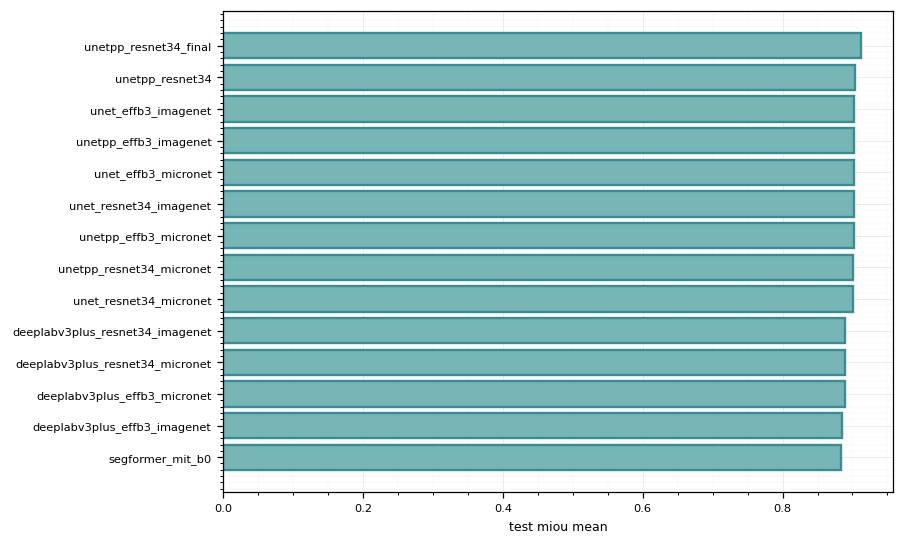

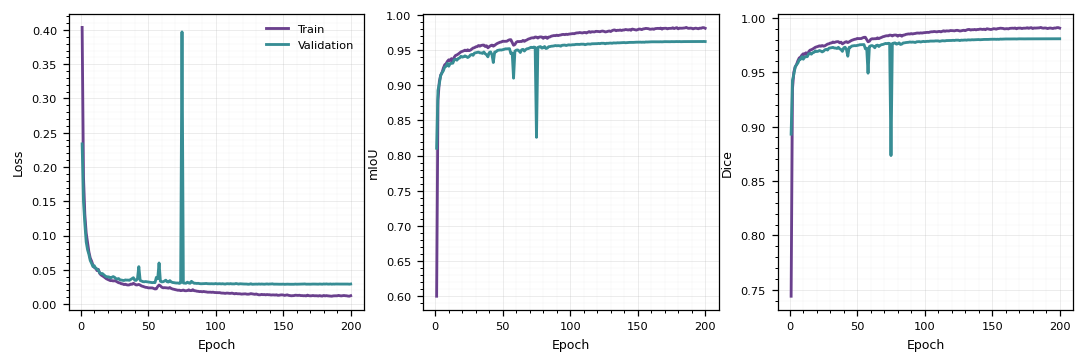

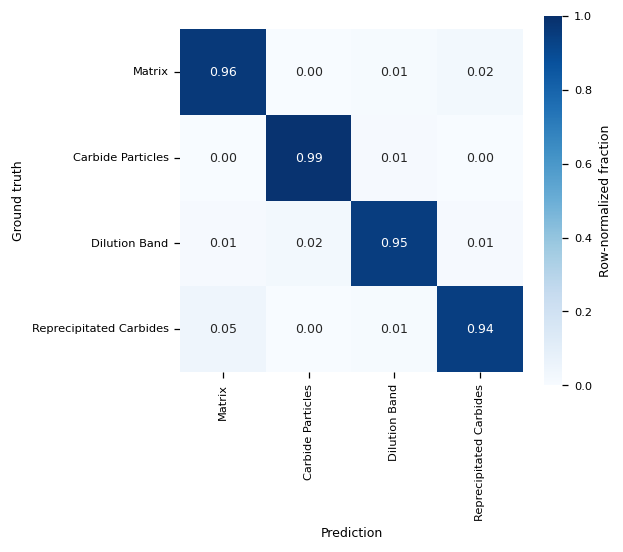

In [22]:
def plot_leaderboard(metric: str = "test_miou_mean") -> mpl.figure.Figure:
    table = leaderboard.sort_values(metric, ascending=True)
    fig, ax = plt.subplots(figsize=(7.2, 5.2))
    ax.barh(table["model_name"], table[metric], color=THEME["teal"], edgecolor=THEME["teal_edge"], linewidth=1.4)
    ax.set_xlabel(metric.replace("_", " "))
    ax.set_ylabel("")
    apply_axis_style(ax)
    return fig


def training_curve_table(model_name: str) -> pd.DataFrame:
    data = history_df[history_df["model_name"] == model_name]
    return data.groupby("epoch", as_index=False).agg(
        train_loss=("train_loss", "mean"),
        val_loss=("val_loss", "mean"),
        train_miou=("train_miou", "mean"),
        val_miou=("val_miou", "mean"),
        train_dice=("train_dice", "mean"),
        val_dice=("val_dice", "mean"),
    )


def plot_training_curve(model_name: str) -> mpl.figure.Figure:
    curve = training_curve_table(model_name)
    fig, axes = plt.subplots(1, 3, figsize=(10.8, 3.2))
    axes[0].plot(curve["epoch"], curve["train_loss"], color=THEME["purple_edge"], label="Train")
    axes[0].plot(curve["epoch"], curve["val_loss"], color=THEME["teal_edge"], label="Validation")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend(frameon=False)
    axes[1].plot(curve["epoch"], curve["train_miou"], color=THEME["purple_edge"], label="Train")
    axes[1].plot(curve["epoch"], curve["val_miou"], color=THEME["teal_edge"], label="Validation")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("mIoU")
    axes[2].plot(curve["epoch"], curve["train_dice"], color=THEME["purple_edge"], label="Train")
    axes[2].plot(curve["epoch"], curve["val_dice"], color=THEME["teal_edge"], label="Validation")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Dice")
    for ax in axes:
        apply_axis_style(ax)
    return fig


def plot_confusion_matrix(model_name: str, seed: int = 1) -> mpl.figure.Figure:
    cm = pd.read_csv(CHECKPOINT_DIR / model_name / f"seed_{seed}" / "confusion_matrix.csv", index_col=0).to_numpy()
    cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    fig, ax = plt.subplots(figsize=(4.6, 4.0))
    sns.heatmap(
        cm_norm,
        vmin=0,
        vmax=1,
        cmap="Blues",
        annot=True,
        fmt=".2f",
        square=True,
        cbar_kws={"label": "Row-normalized fraction"},
        xticklabels=[class_label(n) for n in CFG.class_names],
        yticklabels=[class_label(n) for n in CFG.class_names],
        ax=ax,
    )
    ax.set_xlabel("Prediction")
    ax.set_ylabel("Ground truth")
    apply_axis_style(ax, grid=False)
    return fig


final_model_name = "unetpp_resnet34_final"
best_model_name = leaderboard.iloc[0]["model_name"]
training_curve_table(final_model_name).to_csv(TABLE_DIR / f"{final_model_name}_training_curve.csv", index=False)
show_and_save(plot_leaderboard(), FIGURE_DIR / "paper_model_leaderboard_miou")
show_and_save(plot_training_curve(final_model_name), FIGURE_DIR / f"{final_model_name}_training_curve")
show_and_save(plot_confusion_matrix(final_model_name, seed=1), FIGURE_DIR / f"{final_model_name}_confusion_matrix_seed1")

## 22. Final-Model Material Characterization

The final model is used to quantify phase fractions, carbide morphology, and phase spatial profiles from the held-out SEM600 predictions.

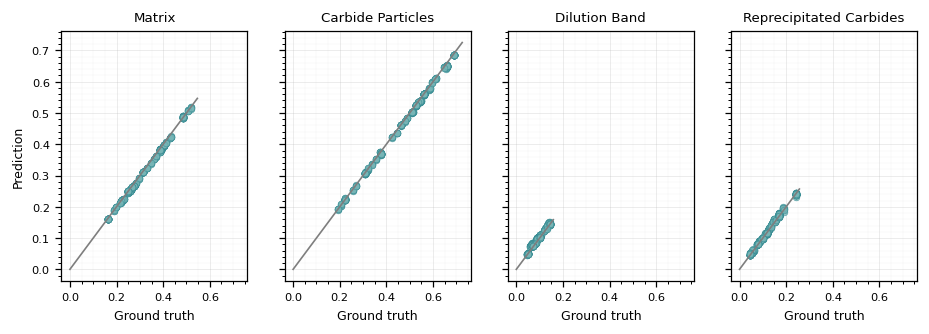

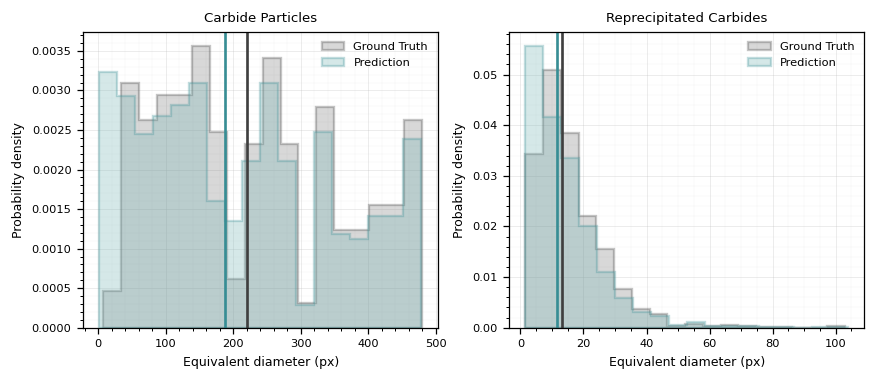

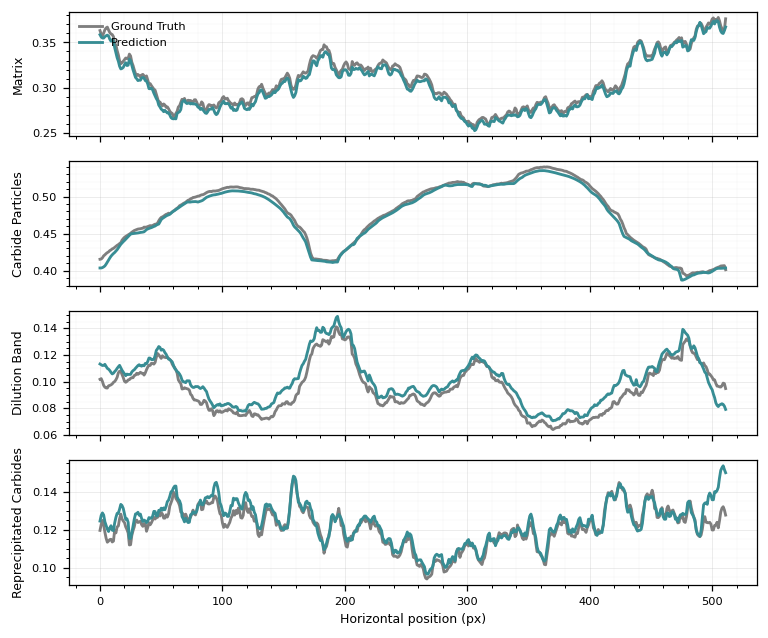

Archived outputs to /teamspace/studios/this_studio/paper_outputs.zip


In [23]:
def load_material_tables(model_name: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    fractions, components, profiles = [], [], []
    for seed in CFG.seed_values:
        run_dir = CHECKPOINT_DIR / model_name / f"seed_{seed}"
        fractions.append(pd.read_csv(run_dir / "phase_fraction_by_image.csv").assign(seed=seed))
        components.append(pd.read_csv(run_dir / "particle_morphology.csv").assign(seed=seed))
        profiles.append(pd.read_csv(run_dir / "phase_spatial_profiles.csv").assign(seed=seed))
    return pd.concat(fractions, ignore_index=True), pd.concat(components, ignore_index=True), pd.concat(profiles, ignore_index=True)


def plot_phase_fraction_agreement(fractions: pd.DataFrame) -> mpl.figure.Figure:
    records = []
    for key, group in fractions.groupby(["seed", "filename"]):
        gt = group[group["measurement"] == "ground_truth"].iloc[0]
        pr = group[group["measurement"] == "prediction"].iloc[0]
        for class_name in CFG.class_names:
            records.append({"class_name": class_name, "ground_truth": gt[class_name], "prediction": pr[class_name]})
    table = pd.DataFrame(records)
    fig, axes = plt.subplots(1, len(CFG.class_names), figsize=(9.2, 2.7), sharex=True, sharey=True)
    for ax, class_name in zip(axes, CFG.class_names):
        sub = table[table["class_name"] == class_name]
        ax.scatter(sub["ground_truth"], sub["prediction"], s=16, color=THEME["teal"], edgecolor=THEME["teal_edge"], linewidth=0.4, alpha=0.75)
        lim = [0, max(sub["ground_truth"].max(), sub["prediction"].max()) * 1.05]
        ax.plot(lim, lim, color=THEME["gray"], linewidth=1.0)
        ax.set_title(class_label(class_name))
        ax.set_xlabel("Ground truth")
        apply_axis_style(ax)
    axes[0].set_ylabel("Prediction")
    return fig


def plot_particle_size_distribution(components: pd.DataFrame) -> mpl.figure.Figure:
    keep = components[components["class_name"].isin(["carbide_particles", "reprecipitated_carbides"])].copy()
    fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.2))
    for ax, class_name in zip(axes, ["carbide_particles", "reprecipitated_carbides"]):
        sub = keep[keep["class_name"] == class_name]
        for measurement, color, edge in [("ground_truth", THEME["gray"], "#3F3F3F"), ("prediction", THEME["teal"], THEME["teal_edge"])]:
            values = sub[sub["measurement"] == measurement]["equivalent_diameter_px"].dropna()
            ax.hist(values, bins=18, density=True, histtype="stepfilled", alpha=0.30, color=color, edgecolor=edge, linewidth=1.4, label=measurement.replace("_", " ").title())
            if len(values):
                ax.axvline(values.median(), color=edge, linewidth=1.6)
        ax.set_title(class_label(class_name))
        ax.set_xlabel("Equivalent diameter (px)")
        ax.set_ylabel("Probability density")
        ax.legend(frameon=False)
        apply_axis_style(ax)
    return fig


def plot_phase_spatial_profile(profiles: pd.DataFrame) -> mpl.figure.Figure:
    prof = profiles.groupby(["measurement", "class_name", "x"], as_index=False)["area_fraction"].mean()
    fig, axes = plt.subplots(len(CFG.class_names), 1, figsize=(7.4, 6.2), sharex=True)
    for ax, class_name in zip(axes, CFG.class_names):
        sub = prof[prof["class_name"] == class_name]
        for measurement, color in [("ground_truth", THEME["gray"]), ("prediction", THEME["teal_edge"])]:
            line = sub[sub["measurement"] == measurement]
            ax.plot(line["x"], line["area_fraction"], color=color, linewidth=1.7, label=measurement.replace("_", " ").title())
        ax.set_ylabel(class_label(class_name))
        apply_axis_style(ax)
    axes[0].legend(frameon=False, loc="upper left")
    axes[-1].set_xlabel("Horizontal position (px)")
    return fig


final_model_name = "unetpp_resnet34_final"
fractions_df, components_df, profiles_df = load_material_tables(final_model_name)
fractions_df.to_csv(TABLE_DIR / f"{final_model_name}_phase_fraction_by_image.csv", index=False)
components_df.to_csv(TABLE_DIR / f"{final_model_name}_particle_morphology.csv", index=False)
profiles_df.to_csv(TABLE_DIR / f"{final_model_name}_phase_spatial_profiles.csv", index=False)

show_and_save(plot_phase_fraction_agreement(fractions_df), FIGURE_DIR / f"{final_model_name}_phase_fraction_agreement")
show_and_save(plot_particle_size_distribution(components_df), FIGURE_DIR / f"{final_model_name}_particle_size_distribution")
show_and_save(plot_phase_spatial_profile(profiles_df), FIGURE_DIR / f"{final_model_name}_phase_spatial_profile")

zip_path = shutil.make_archive(str(CFG.output_dir), "zip", root_dir=CFG.output_dir)
print(f"Archived outputs to {zip_path}")